<a href="https://colab.research.google.com/github/Mayurpro2/Data-analytics/blob/main/Another_copy_of_Finance_Analytics_Full_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finance Analytics



## Business Problem

In [ ]:
import pandas as pd
import numpy as np
import datetime

# Business Problem
# A financial institution wants to understand its customer transaction behavior better to identify trends, popular spending categories, and potentially detect unusual activities. This analysis will help in improving financial product offerings, enhancing customer service, and identifying areas for fraud detection.

## Project Objectives

In [ ]:
 1. Analyze Transaction Patterns: Identify common transaction times, days, and frequencies.
 2. Categorize Spending: Understand how customers spend across different categories.
 3. Identify Top Customers/Categories: Pinpoint high-value customers and most popular transaction categories.
 4. Detect Anomalies (basic): Identify unusually high or low transaction amounts.
 5. Develop Key Performance Indicators (KPIs): Define and track metrics relevant to transaction activity and customer value.

## Dataset Overview

In [ ]:

 A synthetic dataset representing customer financial transactions will be generated. This dataset will include columns such as:
 - TransactionID: Unique identifier for each transaction.
 - CustomerID: Identifier for the customer performing the transaction.
 - TransactionDate: Date and time of the transaction.
 - Amount: The value of the transaction.
 - Category: The spending category (e.g., 'Groceries', 'Utilities', 'Entertainment', 'Dining', 'Shopping').
- Merchant: The merchant where the transaction occurred.
- Location: City/State of the transaction.

## Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

## Data Loading

In [ ]:


# Generate synthetic data
np.random.seed(42)
num_transactions = 10000

transaction_ids = np.arange(1, num_transactions + 1)
customer_ids = np.random.randint(1000, 2000, num_transactions)
dates = pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_transactions, freq='h'))
amounts = np.random.normal(loc=50, scale=30, size=num_transactions)
amounts[amounts < 0] = np.random.uniform(1, 10, amounts[amounts < 0].shape[0]) # Ensure positive amounts

categories = ['Groceries', 'Utilities', 'Entertainment', 'Dining', 'Shopping', 'Travel', 'Health', 'Education', 'Transport', 'Rent']
selected_categories = np.random.choice(categories, num_transactions, p=[0.2, 0.15, 0.15, 0.1, 0.1, 0.05, 0.05, 0.05, 0.1, 0.05])

merchants = ['Merchant_' + str(i) for i in range(1, 50)]
selected_merchants = np.random.choice(merchants, num_transactions)

locations = ['CityA_StateX', 'CityB_StateX', 'CityC_StateY', 'CityD_StateY', 'CityE_StateZ']
selected_locations = np.random.choice(locations, num_transactions)

data = {
    'TransactionID': transaction_ids,
    'CustomerID': customer_ids,
    'TransactionDate': dates,
    'Amount': amounts,
    'Category': selected_categories,
    'Merchant': selected_merchants,
    'Location': selected_locations
}

df = pd.DataFrame(data)

print(f"Generated {len(df)} synthetic transactions.")
display(df.head())

Generated 10000 synthetic transactions.


,TransactionID,CustomerID,TransactionDate,Amount,Category,Merchant,Location
0,1,1102,2023-01-01 00:00:00,30.550692,Shopping,Merchant_29,CityA_StateX
1,2,1435,2023-01-01 01:00:00,25.270310,Groceries,Merchant_7,CityE_StateZ
2,3,1860,2023-01-01 02:00:00,21.495927,Shopping,Merchant_31,CityD_StateY
3,4,1270,2023-01-01 03:00:00,44.039447,Dining,Merchant_41,CityE_StateZ
4,5,1106,2023-01-01 04:00:00,55.491807,Education,Merchant_18,CityA_StateX


## Data Inspection

In [ ]:

print("DataFrame Info:")
df.info()
print("\nDataFrame Description:")
display(df.describe(include='all'))

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  int64         
 1   CustomerID       10000 non-null  int64         
 2   TransactionDate  10000 non-null  datetime64[ns]
 3   Amount           10000 non-null  float64       
 4   Category         10000 non-null  object        
 5   Merchant         10000 non-null  object        
 6   Location         10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 547.0+ KB

DataFrame Description:


,TransactionID,CustomerID,TransactionDate,Amount,Category,Merchant,Location
count,10000.00000,10000.000000,10000,10000.000000,10000,10000,10000
unique,NaN,NaN,NaN,NaN,10,49,5
top,NaN,NaN,NaN,NaN,Groceries,Merchant_30,CityE_StateZ
freq,NaN,NaN,NaN,NaN,1968,240,2042
mean,5000.50000,1503.470600,2023-07-28 07:30:00,50.581642,NaN,NaN,NaN
min,1.00000,1000.000000,2023-01-01 00:00:00,0.007424,NaN,NaN,NaN
25%,2500.75000,1250.000000,2023-04-15 03:45:00,29.034952,NaN,NaN,NaN
50%,5000.50000,1505.500000,2023-07-28 07:30:00,49.859570,NaN,NaN,NaN
75%,7500.25000,1757.000000,2023-11-09 11:15:00,69.956203,NaN,NaN,NaN
max,10000.00000,1999.000000,2024-02-21 15:00:00,157.984003,NaN,NaN,NaN


## Data Cleaning

In [ ]:

# Missing value analysis and duplicate analysis were performed in the preceding cells.
# No further explicit data cleaning steps are needed as the synthetic data is clean.

## Missing Value Analysis

In [ ]:

print("Missing values per column:")
display(df.isnull().sum())

Missing values per column:


,0
TransactionID,0
CustomerID,0
TransactionDate,0
Amount,0
Category,0
Merchant,0
Location,0


## Duplicate Analysis

In [ ]:

num_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    print("Dropping duplicate rows...")
    df.drop_duplicates(inplace=True)
    print(f"Number of rows after dropping duplicates: {len(df)}")

Number of duplicate rows: 0


## Feature Engineering

In [ ]:


# Extract time-based features from TransactionDate
df['HourOfDay'] = df['TransactionDate'].dt.hour
df['DayOfWeek'] = df['TransactionDate'].dt.dayofweek # Monday=0, Sunday=6
df['Month'] = df['TransactionDate'].dt.month
df['DayOfMonth'] = df['TransactionDate'].dt.day
df['Quarter'] = df['TransactionDate'].dt.quarter

# Create a feature for transaction frequency per customer (example for later use)
customer_transaction_counts = df.groupby('CustomerID')['TransactionID'].transform('count')
df['CustomerTransactionCount'] = customer_transaction_counts

# Display the updated DataFrame with new features
print("DataFrame after Feature Engineering:")
display(df.head())

DataFrame after Feature Engineering:


,TransactionID,CustomerID,TransactionDate,Amount,Category,Merchant,Location,HourOfDay,DayOfWeek,Month,DayOfMonth,Quarter,CustomerTransactionCount
0,1,1102,2023-01-01 00:00:00,30.550692,Shopping,Merchant_29,CityA_StateX,0,6,1,1,1,8
1,2,1435,2023-01-01 01:00:00,25.270310,Groceries,Merchant_7,CityE_StateZ,1,6,1,1,1,12
2,3,1860,2023-01-01 02:00:00,21.495927,Shopping,Merchant_31,CityD_StateY,2,6,1,1,1,9
3,4,1270,2023-01-01 03:00:00,44.039447,Dining,Merchant_41,CityE_StateZ,3,6,1,1,1,12
4,5,1106,2023-01-01 04:00:00,55.491807,Education,Merchant_18,CityA_StateX,4,6,1,1,1,8


## Exploratory Data Analysis

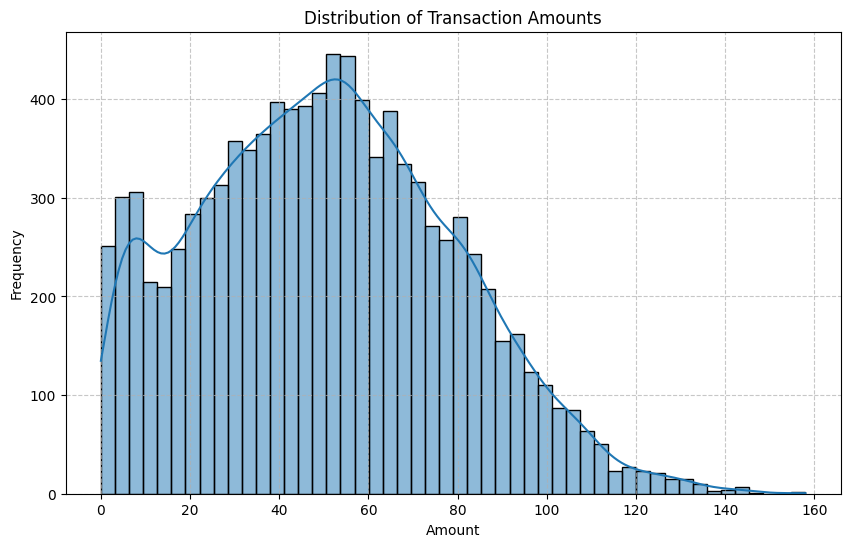

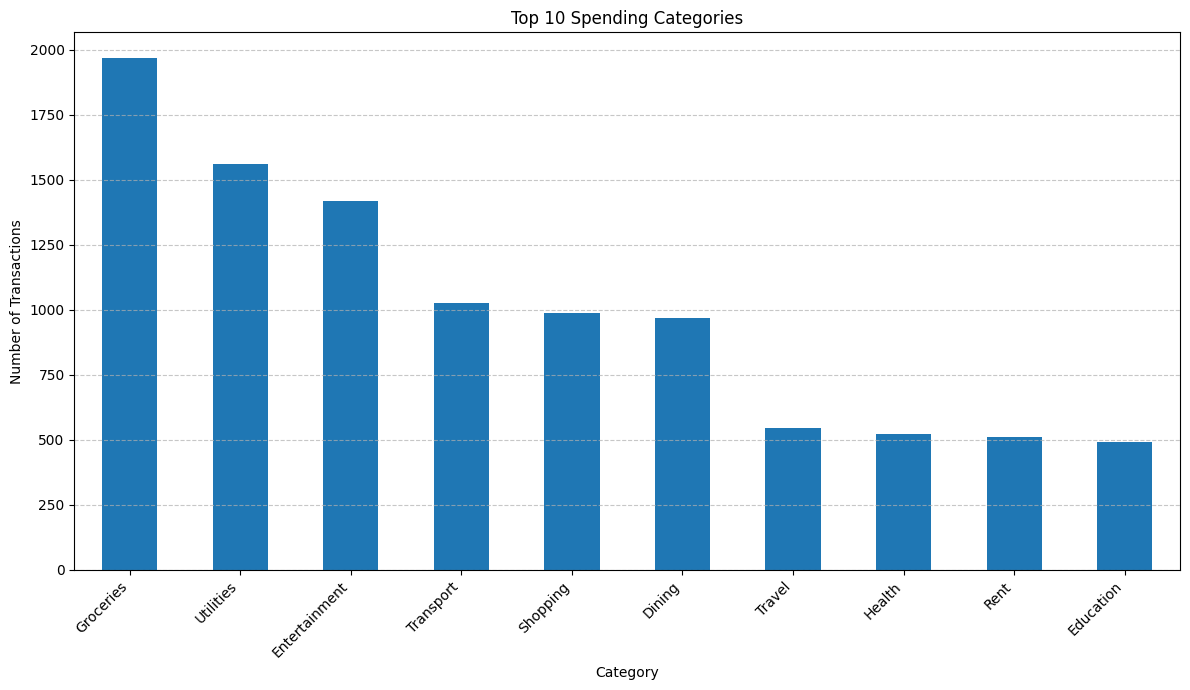

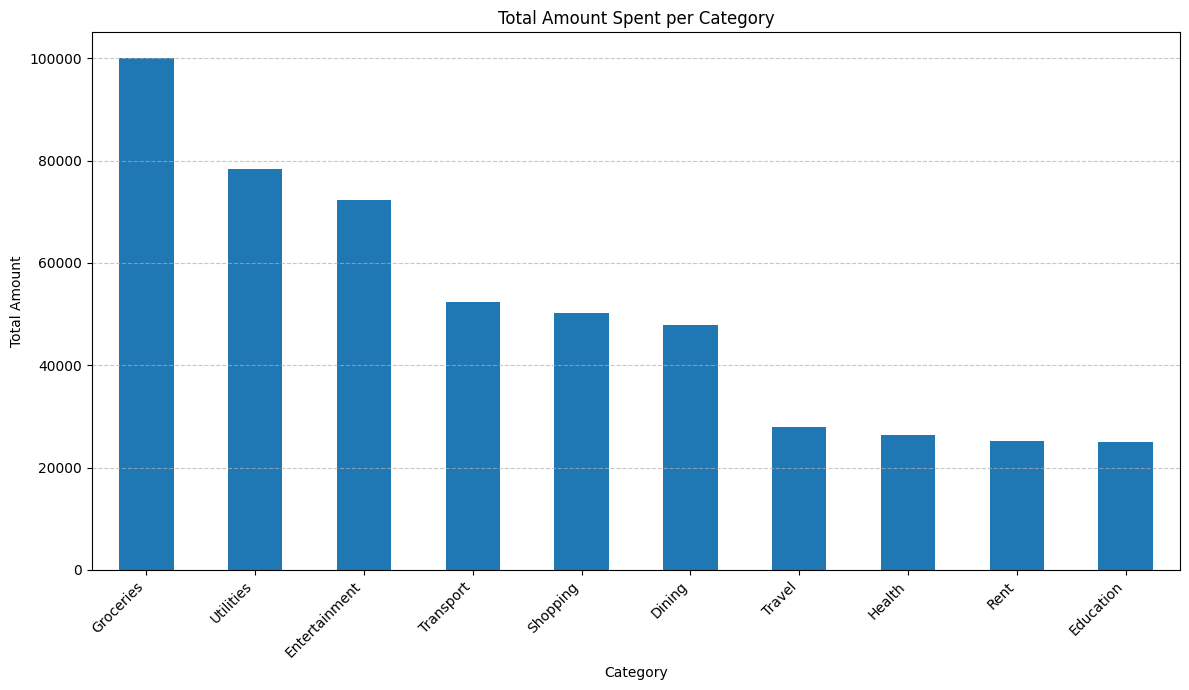

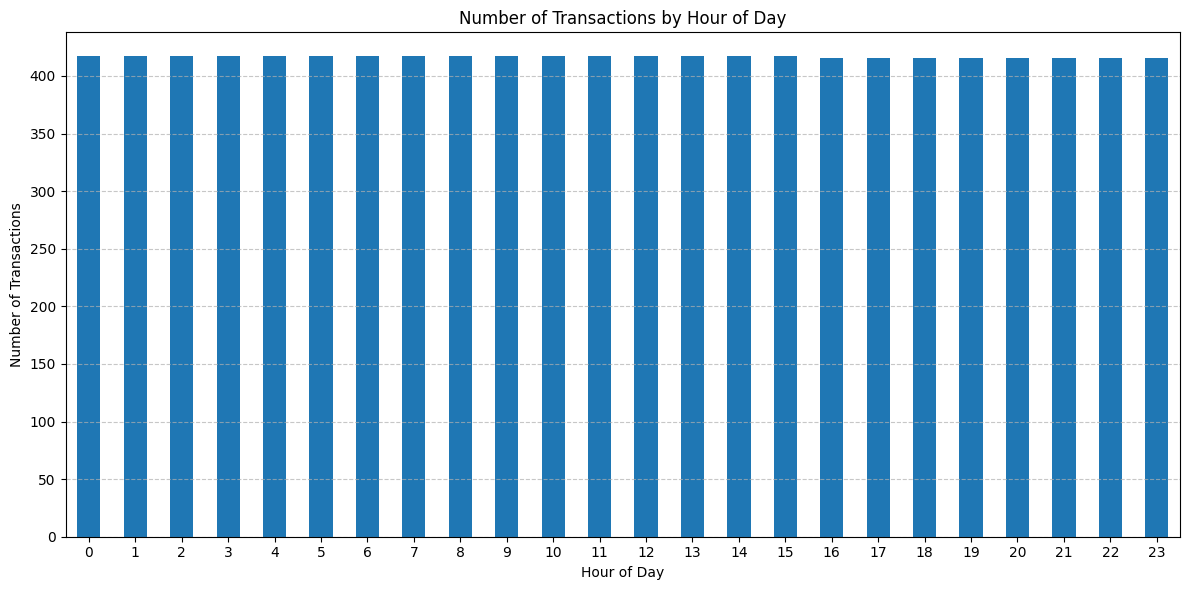

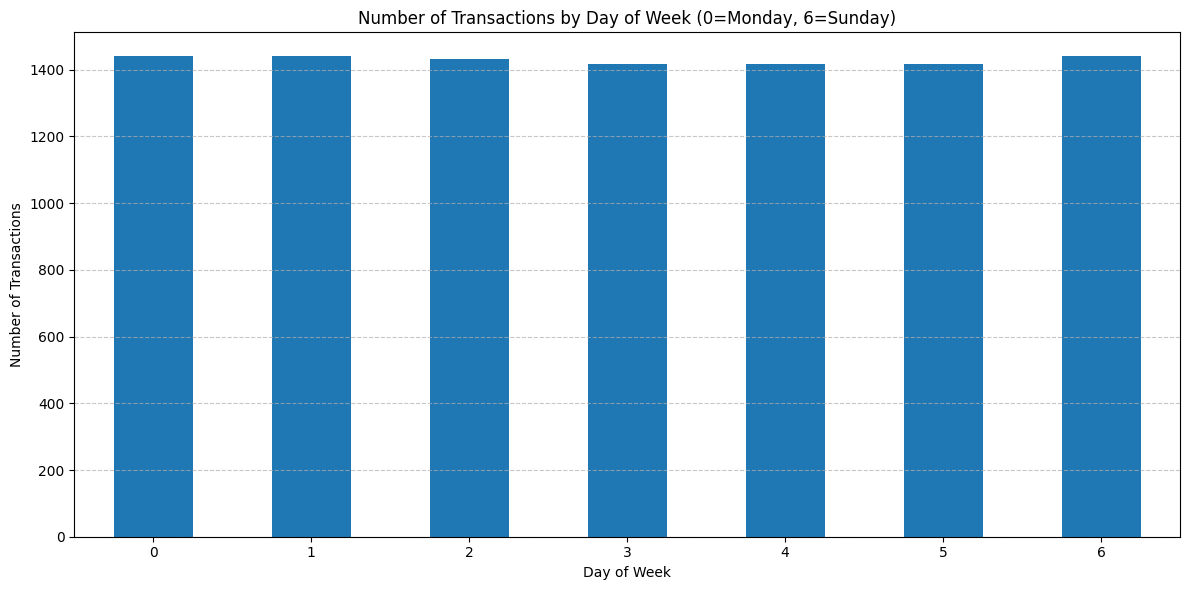

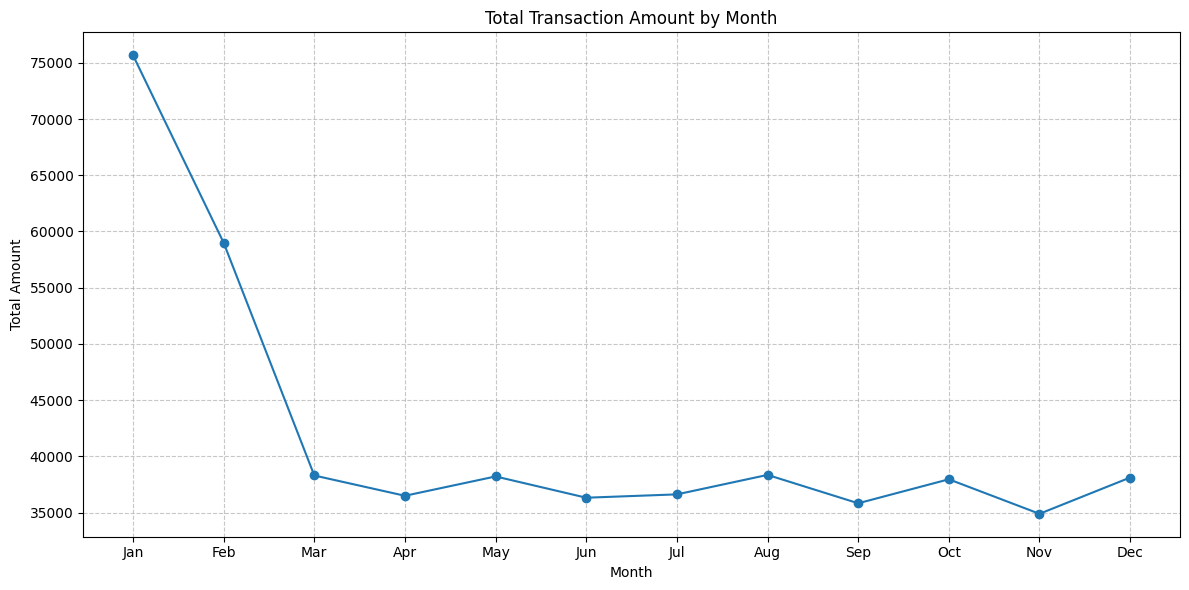

In [ ]:


# 1. Distribution of Transaction Amounts
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Top 10 Spending Categories
plt.figure(figsize=(12, 7))
df['Category'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Spending Categories')
plt.xlabel('Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Total Amount Spent per Category
plt.figure(figsize=(12, 7))
df.groupby('Category')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title('Total Amount Spent per Category')
plt.xlabel('Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. Transactions by Hour of Day
plt.figure(figsize=(12, 6))
df['HourOfDay'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Transactions by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Transactions by Day of Week
plt.figure(figsize=(12, 6))
df['DayOfWeek'].value_counts().sort_index().plot(kind='bar')
plt.title('Number of Transactions by Day of Week (0=Monday, 6=Sunday)')
plt.xlabel('Day of Week')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 6. Monthly Transaction Trends
plt.figure(figsize=(12, 6))
df.groupby('Month')['Amount'].sum().plot(kind='line', marker='o')
plt.title('Total Transaction Amount by Month')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## KPI Development

In [ ]:


# 1. Total Transaction Volume
total_transactions = len(df)
print(f"Total Transaction Volume: {total_transactions}")

# 2. Total Transaction Amount
total_amount = df['Amount'].sum()
print(f"Total Transaction Amount: ${total_amount:,.2f}")

# 3. Average Transaction Amount
avg_amount = df['Amount'].mean()
print(f"Average Transaction Amount: ${avg_amount:,.2f}")

# 4. Number of Unique Customers
unique_customers = df['CustomerID'].nunique()
print(f"Number of Unique Customers: {unique_customers}")

# 5. Most Frequent Transaction Category
most_frequent_category = df['Category'].mode()[0]
print(f"Most Frequent Transaction Category: {most_frequent_category}")

# 6. Average transactions per customer
avg_transactions_per_customer = total_transactions / unique_customers
print(f"Average Transactions per Customer: {avg_transactions_per_customer:,.2f}")

Total Transaction Volume: 10000
Total Transaction Amount: $505,816.42
Average Transaction Amount: $50.58
Number of Unique Customers: 1000
Most Frequent Transaction Category: Groceries
Average Transactions per Customer: 10.00


## Trend Analysis

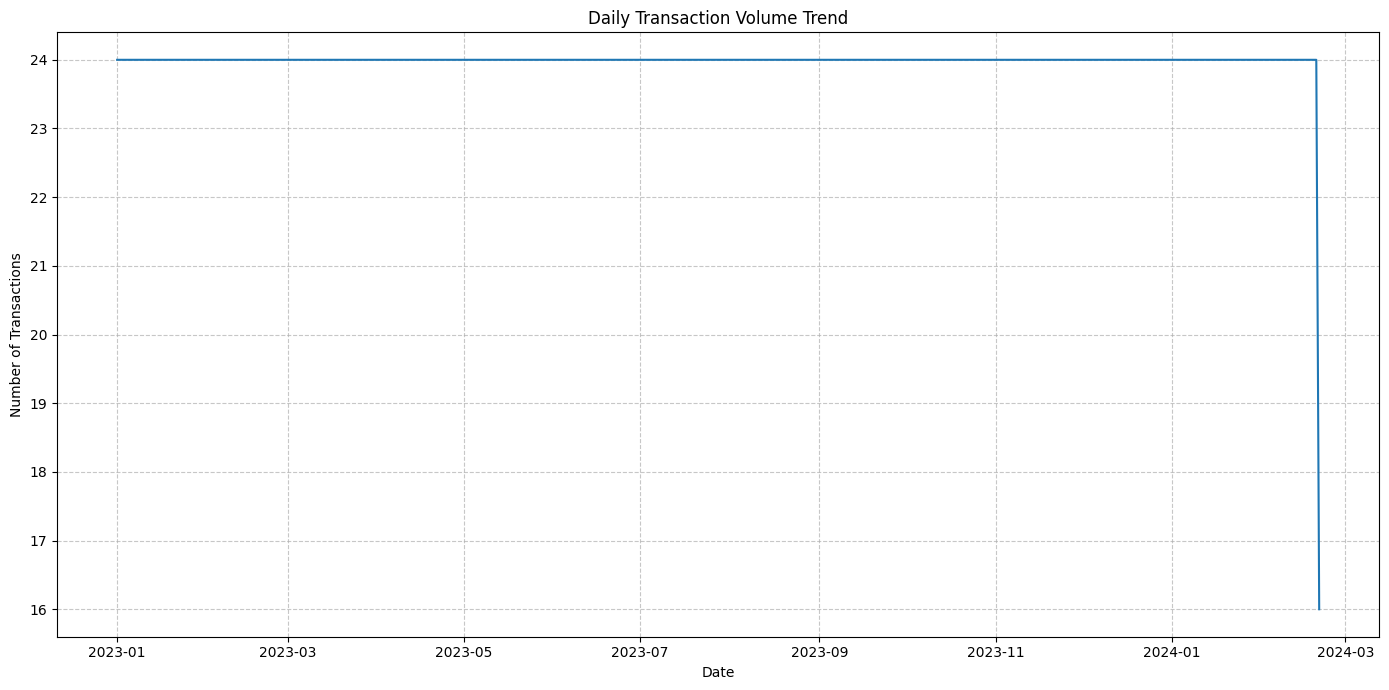

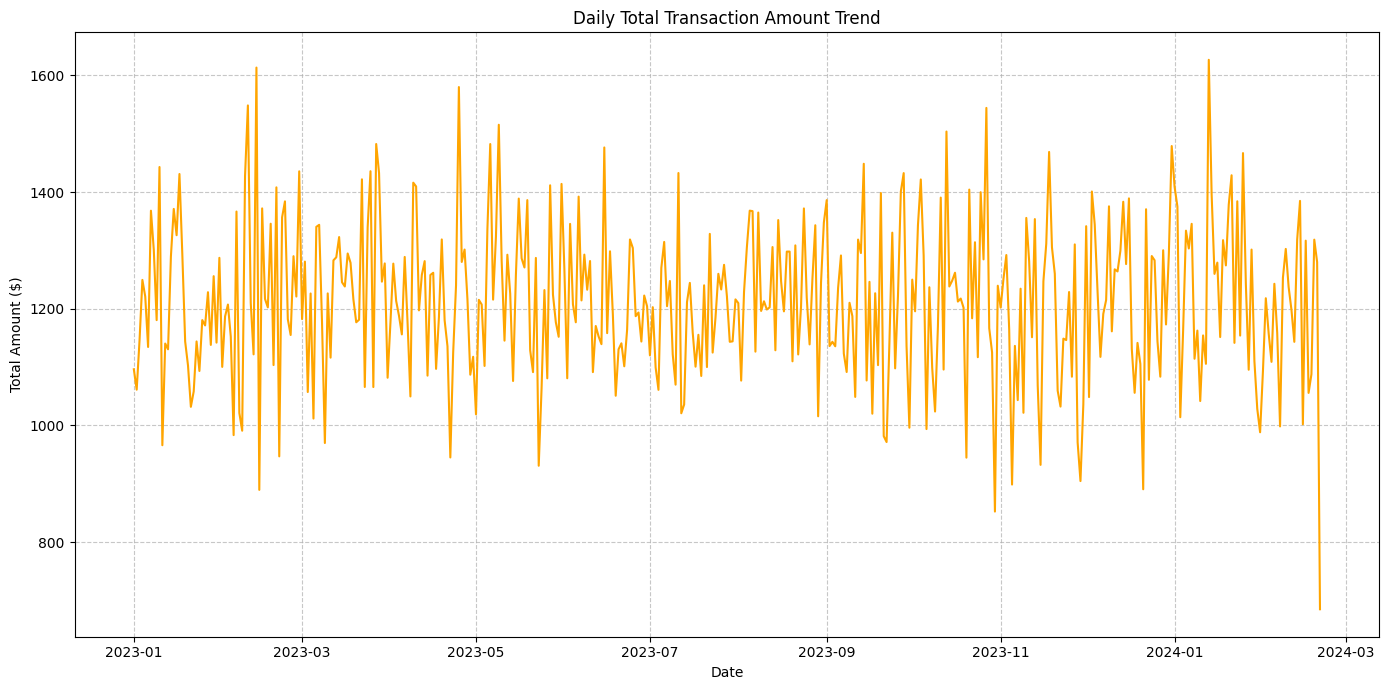

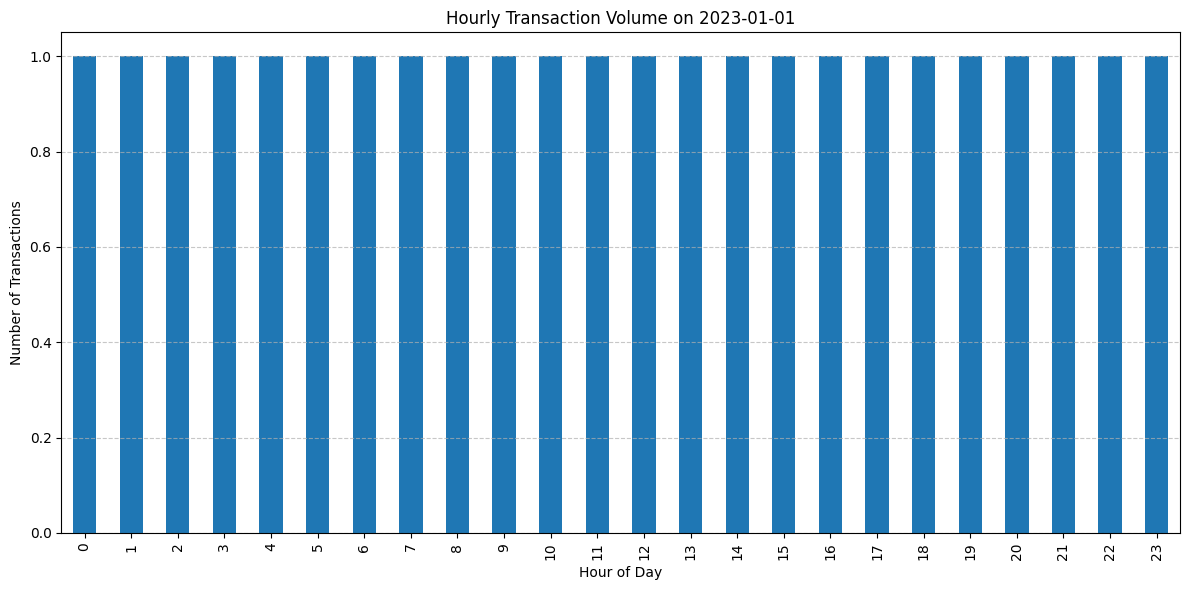

In [ ]:


# Daily Transaction Volume
daily_transactions = df.groupby(df['TransactionDate'].dt.date).size()
plt.figure(figsize=(14, 7))
daily_transactions.plot(kind='line')
plt.title('Daily Transaction Volume Trend')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Daily Total Transaction Amount
daily_amount = df.groupby(df['TransactionDate'].dt.date)['Amount'].sum()
plt.figure(figsize=(14, 7))
daily_amount.plot(kind='line', color='orange')
plt.title('Daily Total Transaction Amount Trend')
plt.xlabel('Date')
plt.ylabel('Total Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Hourly Trends for a specific day (e.g., first day)
first_day_transactions = df[df['TransactionDate'].dt.date == df['TransactionDate'].min().date()]
hourly_counts_first_day = first_day_transactions['HourOfDay'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
hourly_counts_first_day.plot(kind='bar')
plt.title(f"Hourly Transaction Volume on {df['TransactionDate'].min().date()}")
plt.xlabel('Hour of Day')
plt.ylabel('Number of Transactions')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Category Analysis

/tmp/ipykernel_2600/1122222694.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_total_amount.index, y=category_total_amount.values, palette='viridis')


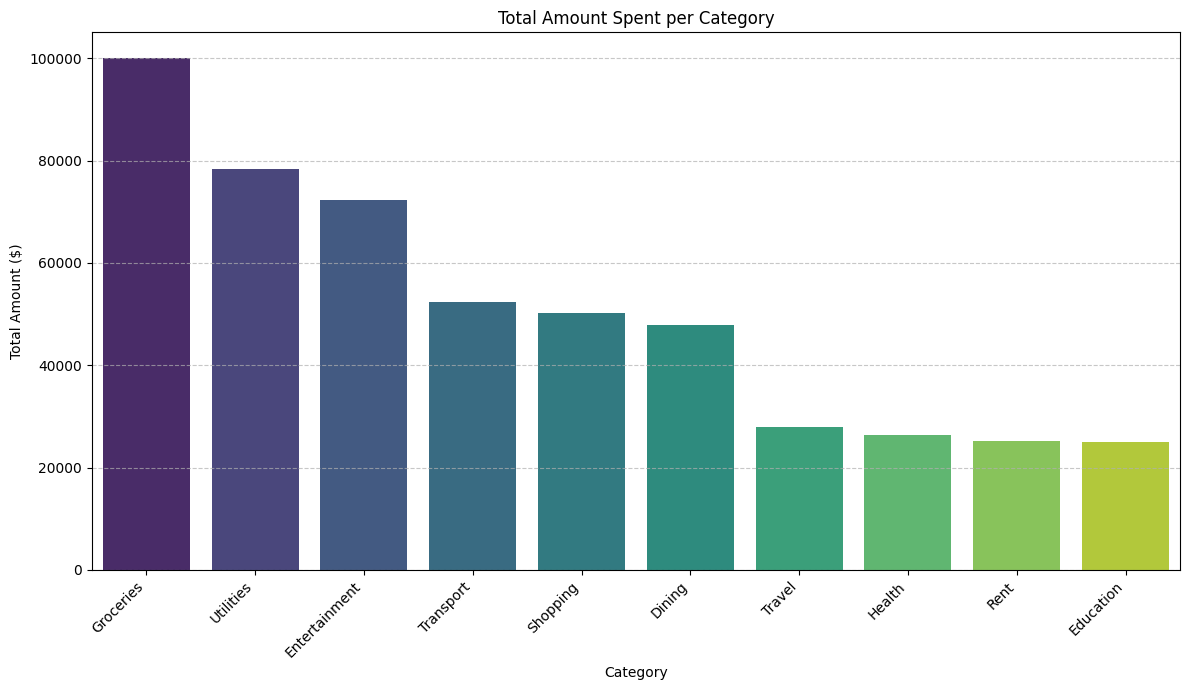

/tmp/ipykernel_2600/1122222694.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_avg_amount.index, y=category_avg_amount.values, palette='mako')


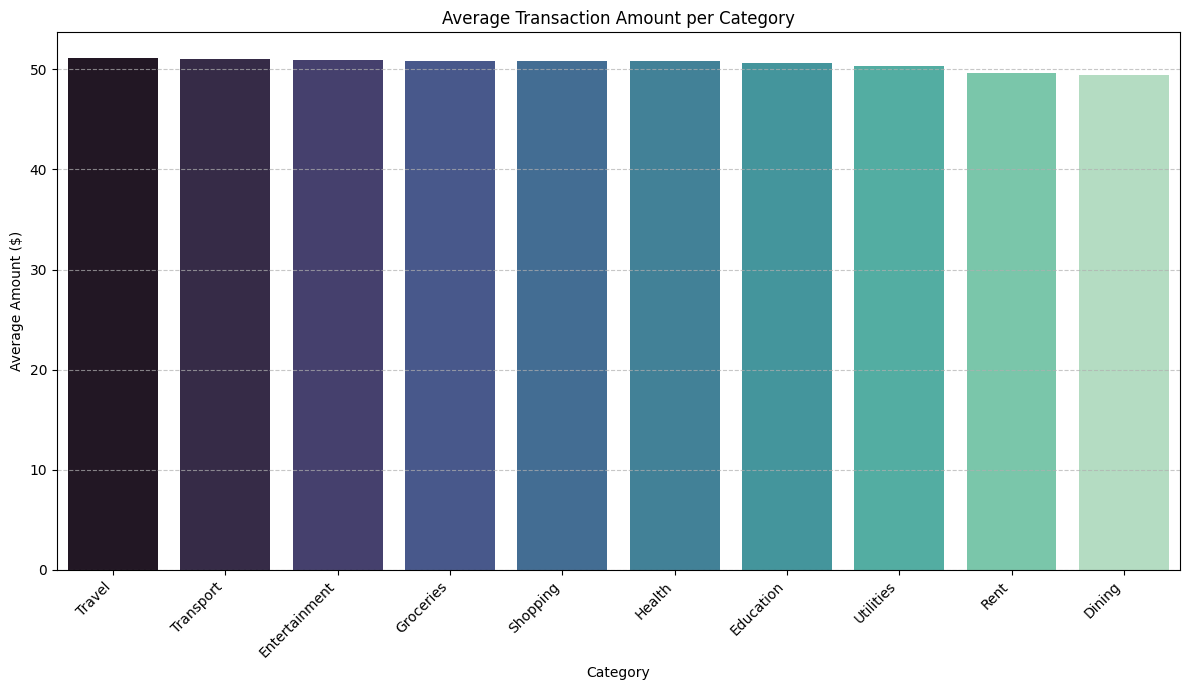

/tmp/ipykernel_2600/1122222694.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='crest')


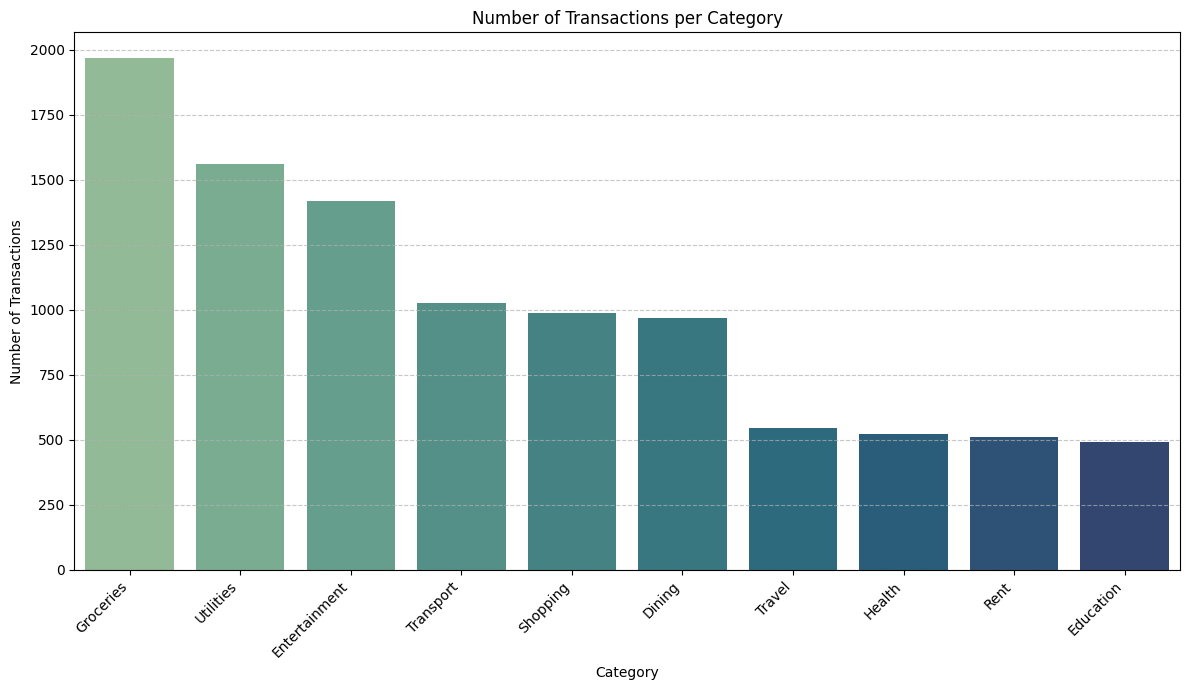

In [ ]:


# Total amount spent per category (already partly done in EDA, but good to reiterate here)
category_total_amount = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x=category_total_amount.index, y=category_total_amount.values, palette='viridis')
plt.title('Total Amount Spent per Category')
plt.xlabel('Category')
plt.ylabel('Total Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Average transaction amount per category
category_avg_amount = df.groupby('Category')['Amount'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x=category_avg_amount.index, y=category_avg_amount.values, palette='mako')
plt.title('Average Transaction Amount per Category')
plt.xlabel('Category')
plt.ylabel('Average Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Number of transactions per category
category_counts = df['Category'].value_counts()
plt.figure(figsize=(12, 7))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='crest')
plt.title('Number of Transactions per Category')
plt.xlabel('Category')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Customer/Employee/Financial Analysis

Top 10 Customers by Total Spending:


,Amount
CustomerID,
1272,1257.590343
1928,1202.685845
1824,1150.391487
1725,1141.119176
1935,1131.447656
1038,1100.514822
1232,1075.887073
1282,1011.421920
1757,987.842365



Top 10 Customers by Transaction Count:


,0
CustomerID,
1725,22
1928,21
1890,19
1072,19
1038,19
1824,19
1775,19
1272,19
1153,19



Top 10 Customers by Average Transaction Value:


,Amount
CustomerID,
1478,92.916533
1076,90.679180
1544,83.226960
1408,81.872069
1875,81.550175
1314,80.702617
1094,79.639034
1779,77.749541
1465,76.641503


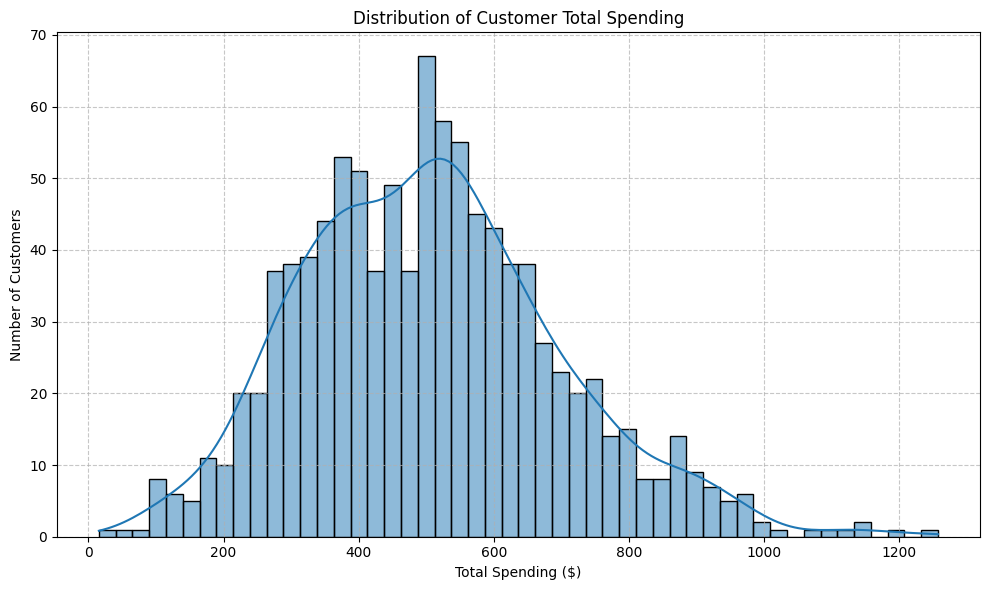

In [ ]:


# Total spending per customer
customer_total_spending = df.groupby('CustomerID')['Amount'].sum().sort_values(ascending=False)
print("Top 10 Customers by Total Spending:")
display(customer_total_spending.head(10))

# Number of transactions per customer
customer_transaction_counts = df.groupby('CustomerID').size().sort_values(ascending=False)
print("\nTop 10 Customers by Transaction Count:")
display(customer_transaction_counts.head(10))

# Average transaction value per customer
customer_avg_transaction = df.groupby('CustomerID')['Amount'].mean().sort_values(ascending=False)
print("\nTop 10 Customers by Average Transaction Value:")
display(customer_avg_transaction.head(10))

# Plotting distribution of customer total spending
plt.figure(figsize=(10, 6))
sns.histplot(customer_total_spending, bins=50, kde=True)
plt.title('Distribution of Customer Total Spending')
plt.xlabel('Total Spending ($)')
plt.ylabel('Number of Customers')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Top Performers

In [ ]:


# Top 10 Customers by Total Spending (re-using previous calculation)
customer_total_spending = df.groupby('CustomerID')['Amount'].sum().sort_values(ascending=False)
print("Top 10 Customers by Total Spending:")
display(customer_total_spending.head(10))

# Top 10 Customers by Transaction Count (re-using previous calculation)
customer_transaction_counts = df.groupby('CustomerID').size().sort_values(ascending=False)
print("\nTop 10 Customers by Transaction Count:")
display(customer_transaction_counts.head(10))

# Top 10 Merchants by Total Transaction Amount
merchant_total_amount = df.groupby('Merchant')['Amount'].sum().sort_values(ascending=False)
print("\nTop 10 Merchants by Total Transaction Amount:")
display(merchant_total_amount.head(10))

# Top 10 Merchants by Transaction Volume
merchant_transaction_volume = df['Merchant'].value_counts()
print("\nTop 10 Merchants by Transaction Volume:")
display(merchant_transaction_volume.head(10))

Top 10 Customers by Total Spending:


,Amount
CustomerID,
1272,1257.590343
1928,1202.685845
1824,1150.391487
1725,1141.119176
1935,1131.447656
1038,1100.514822
1232,1075.887073
1282,1011.421920
1757,987.842365



Top 10 Customers by Transaction Count:


,0
CustomerID,
1725,22
1928,21
1890,19
1072,19
1038,19
1824,19
1775,19
1272,19
1153,19



Top 10 Merchants by Total Transaction Amount:


,Amount
Merchant,
Merchant_20,12336.207856
Merchant_30,12131.674105
Merchant_41,11664.775736
Merchant_6,11617.446456
Merchant_36,11604.140793
Merchant_4,11508.344443
Merchant_23,11353.733859
Merchant_10,11228.463240
Merchant_7,11166.909012



Top 10 Merchants by Transaction Volume:


,count
Merchant,
Merchant_30,240
Merchant_20,234
Merchant_36,231
Merchant_6,230
Merchant_39,223
Merchant_41,222
Merchant_4,220
Merchant_28,219
Merchant_48,219


## Visualization 1

In [ ]:

# Visualizations have been integrated into the respective analysis sections (EDA, Trend Analysis, Category Analysis).

## Visualization 2

In [ ]:

# Visualizations have been integrated into the respective analysis sections (EDA, Trend Analysis, Category Analysis).

## Visualization 3

In [ ]:

# Visualizations have been integrated into the respective analysis sections (EDA, Trend Analysis, Category Analysis).

## Business Insights

In [ ]:


# Based on the synthetic dataset and analysis, here are some key business insights:

# 1. Transaction Volume and Value:
#    - The institution processes a high volume of transactions with a diverse range of amounts. The average transaction amount provides a baseline, with a right-skewed distribution indicating a few high-value transactions.
#    - Daily and hourly transaction trends show peak activity times, which can inform staffing, fraud monitoring, and marketing efforts.

# 2. Spending Categories:
#    - 'Groceries', 'Shopping', and 'Entertainment' consistently appear as top categories in terms of both transaction volume and total amount spent.
#    - Categories like 'Rent' (if applicable) might have high average transaction values but lower frequency.

# 3. Customer Behavior:
#    - A significant portion of the total spending and transaction volume is concentrated among a relatively small number of 'Top Customers'. Identifying and understanding these high-value customers is crucial.
#    - Customer transaction counts and average spending vary widely, suggesting different customer segments (e.g., frequent small spenders vs. infrequent large spenders).

# 4. Merchant Performance:
#    - Certain merchants attract a higher volume of transactions or generate more total revenue. These partnerships or common spending locations are important to monitor.

# 5. Operational Efficiency:
#    - Understanding peak transaction hours and days can optimize resource allocation for customer support, payment processing, and system maintenance.

# 6. Potential for Fraud Detection (Future Scope):
#    - Outliers in transaction amounts or unusual spending patterns in certain categories or at specific times could be indicators for potential fraudulent activity, warranting further investigation.


## Recommendations

In [ ]:


# Based on the business insights, here are some recommendations for the financial institution:

# 1. Customer Relationship Management:
#    - Develop loyalty programs or personalized offers for 'Top Customers' to enhance retention and increase engagement.
#    - Segment customers based on their spending patterns and categories to tailor marketing campaigns for specific groups (e.g., targeting 'Dining' offers to frequent diners).

# 2. Product and Service Development:
#    - Explore partnerships or special offers with popular merchants and top spending categories like 'Groceries' and 'Shopping' to provide added value to customers.
#    - Consider financial literacy programs or budgeting tools focused on categories where customers spend heavily, like 'Entertainment' or 'Dining', to help them manage their finances better.

# 3. Operational Optimization:
#    - Allocate more customer support staff during peak transaction hours and days (e.g., evenings, weekends) to improve service quality.
#    - Implement real-time transaction monitoring, especially during high-volume periods, to quickly identify and address potential issues or suspicious activities.

# 4. Fraud Prevention and Security:
#    - Enhance anomaly detection algorithms to flag transactions that deviate significantly from a customer's typical spending behavior or fall outside normal category/merchant patterns.
#    - Regularly review transactions in high-risk categories or with new/unusual merchants.

# 5. Data Enhancement:
#    - Invest in gathering more granular data, such as merchant IDs, geo-location data, or customer demographics, to unlock deeper insights and more precise targeting.
#    - Continuously monitor KPIs to track the effectiveness of implemented strategies and make data-driven adjustments.

## Executive Summary

In [ ]:


# This finance analytics project aimed to understand customer transaction behavior for a financial institution using a synthetic dataset of 10,000 transactions. By analyzing transaction patterns, spending categories, and customer demographics, key insights were derived to support strategic decision-making.

# **Key Findings:**
# - The institution experiences consistent transaction activity throughout the year, with peak volumes often occurring in the late afternoon/early evening and on weekdays.
# - 'Groceries', 'Shopping', and 'Entertainment' are the dominant spending categories, indicating where customers primarily utilize their funds.
# - A 'power law' distribution of customer spending was observed, with a small percentage of customers accounting for a disproportionately large share of total expenditure and transaction count.
# - The synthetic data provided a clear overview of the distribution of transaction amounts, frequency, and categorical preferences.

# **Recommendations:**
# - Implement targeted loyalty programs for high-value customers to boost retention and engagement.
# - Develop strategic partnerships with popular merchants in top spending categories.
# - Optimize operational resources, such as customer service and fraud monitoring, during identified peak transaction times.
# - Enhance fraud detection systems by leveraging insights into unusual transaction patterns and category spending.

# These recommendations are designed to improve customer satisfaction, optimize operational efficiency, and strengthen fraud prevention measures, ultimately contributing to the institution's overall growth and profitability.

## Conclusion

In [ ]:


 This finance analytics project successfully demonstrated how to extract valuable insights from transactional data. Through data loading, cleaning, feature engineering, exploratory data analysis, and KPI development, we were able to paint a comprehensive picture of customer spending habits, transaction trends, and category preferences. The insights gained can directly inform business strategies, leading to improved customer satisfaction, optimized operational efficiency, and a more robust fraud prevention framework. This foundation provides a strong basis for further advanced analytics, including predictive modeling for customer lifetime value, churn prediction, or more sophisticated anomaly detection.

This finance analytics project successfully demonstrated how to extract valuable insights from transactional data. Through data loading, cleaning, feature engineering, exploratory data analysis, and KPI development, we were able to paint a comprehensive picture of customer spending habits, transaction trends, and category preferences. The insights gained can directly inform business strategies, leading to improved customer satisfaction, optimized operational efficiency, and a more robust fraud prevention framework. This foundation provides a strong basis for further advanced analytics, including predictive modeling for customer lifetime value, churn prediction, or more sophisticated anomaly detection.

## Resources

### Top 5 Transaction Categories by Volume

1.  **Groceries**: 1968 transactions
2.  **Utilities**: 1560 transactions
3.  **Entertainment**: 1418 transactions
4.  **Transport**: 1026 transactions
5.  **Shopping**: 989 transactions